<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="240">
</a>

# Sigmoid, Bernoulli e Cross-Entropy: a Matemática da Classificação

Material de apoio do artigo da série **Matemática para Machine Learning** no blog da [Sigmoidal](https://sigmoidal.ai).

Implementamos do zero, com NumPy puro: a função sigmoid, a binary cross-entropy a partir da distribuição de Bernoulli, e o treinamento de uma regressão logística com gradient descent, terminando na fronteira de decisão.

## Importações e configurações

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

np.random.seed(42)

## 1. O problema: prever sim ou não

Geramos um dataset sintético de classificação binária com duas features. Cada ponto é um exemplo $(x^{(i)}, y^{(i)})$ com $y \in \{0, 1\}$: duas nuvens gaussianas parcialmente sobrepostas, como em qualquer problema real.

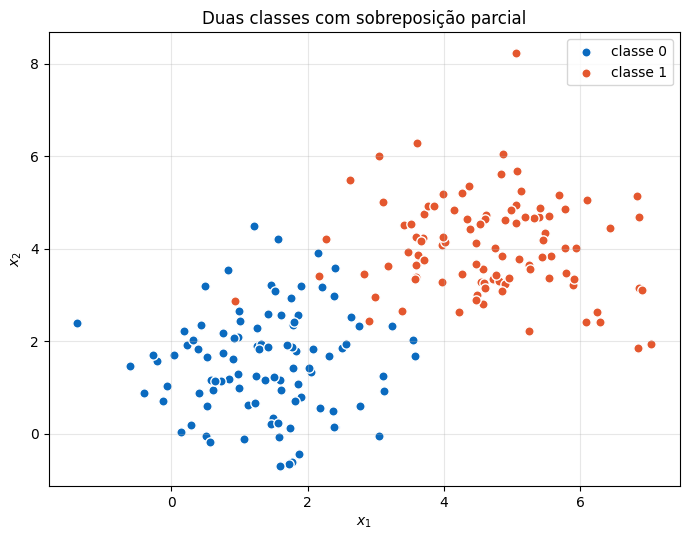

In [2]:
m = 200

# Classe 0 e classe 1: nuvens gaussianas com sobreposicao parcial
X0 = np.random.randn(m // 2, 2) * 1.1 + np.array([1.5, 1.5])
X1 = np.random.randn(m // 2, 2) * 1.1 + np.array([4.5, 4.0])

X = np.vstack([X0, X1])
y = np.concatenate([np.zeros(m // 2), np.ones(m // 2)])

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#0A6ABF", edgecolor="white", s=45, label="classe 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#E4572E", edgecolor="white", s=45, label="classe 1")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Duas classes com sobreposição parcial")
ax.legend()
plt.tight_layout()
plt.show()

## 2. O esmagador: a função sigmoid

A saída linear $z = w^\top x + b$ vai de $-\infty$ a $+\infty$, mas uma probabilidade precisa viver em $(0, 1)$. A **sigmoid** esmaga a reta para dentro desse intervalo:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

In [3]:
def sigmoid(z):
    """Esmaga qualquer numero real para o intervalo (0, 1)."""
    return 1.0 / (1.0 + np.exp(-z))


for z in [-10, -2, 0, 2, 10]:
    print(f"sigmoid({z:+3d}) = {sigmoid(z):.4f}")

sigmoid(-10) = 0.0000
sigmoid( -2) = 0.1192
sigmoid( +0) = 0.5000
sigmoid( +2) = 0.8808
sigmoid(+10) = 1.0000


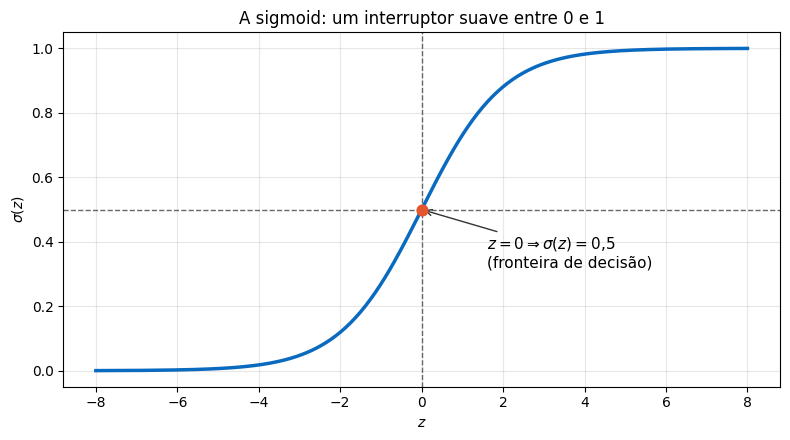

In [4]:
z = np.linspace(-8, 8, 400)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z, sigmoid(z), color="#0A6ABF", linewidth=2.5)
ax.axhline(0.5, color="#666666", linestyle="--", linewidth=1)
ax.axvline(0.0, color="#666666", linestyle="--", linewidth=1)
ax.scatter([0], [0.5], color="#E4572E", zorder=5, s=60)
ax.annotate("$z = 0 \\Rightarrow \\sigma(z) = 0{,}5$\n(fronteira de decisão)",
            xy=(0, 0.5), xytext=(1.6, 0.32), fontsize=11,
            arrowprops=dict(arrowstyle="->", color="#333333"))
ax.set_xlabel("$z$")
ax.set_ylabel("$\\sigma(z)$")
ax.set_title("A sigmoid: um interruptor suave entre 0 e 1")
plt.tight_layout()
plt.show()

## 3. Bernoulli e a binary cross-entropy

Uma variável que só assume 0 ou 1 segue uma distribuição de **Bernoulli**, $p(y \mid x) = \hat{p}^{\,y}(1 - \hat{p})^{1-y}$. Aplicando a receita da verossimilhança (produto sobre os exemplos, logaritmo, sinal de menos e média), o resultado é a **binary cross-entropy**:

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \Big[\, y^{(i)} \log \hat{p}^{(i)} + (1 - y^{(i)}) \log\big(1 - \hat{p}^{(i)}\big) \Big]$$

In [5]:
def bce(y, p_hat, eps=1e-12):
    """Binary cross-entropy media (a cost da classificacao)."""
    p_hat = np.clip(p_hat, eps, 1 - eps)
    return -np.mean(y * np.log(p_hat) + (1 - y) * np.log(1 - p_hat))


# Punicao da confianca errada: y = 0, mas o modelo da 99% para a classe 1
print(f"acertou com confiança (y=1, p=0.99): loss = {bce(np.array([1.0]), np.array([0.99])):.4f}")
print(f"em cima do muro     (y=1, p=0.50): loss = {bce(np.array([1.0]), np.array([0.50])):.4f}")
print(f"errou com confiança (y=0, p=0.99): loss = {bce(np.array([0.0]), np.array([0.99])):.4f}")

acertou com confiança (y=1, p=0.99): loss = 0.0101
em cima do muro     (y=1, p=0.50): loss = 0.6931
errou com confiança (y=0, p=0.99): loss = 4.6052


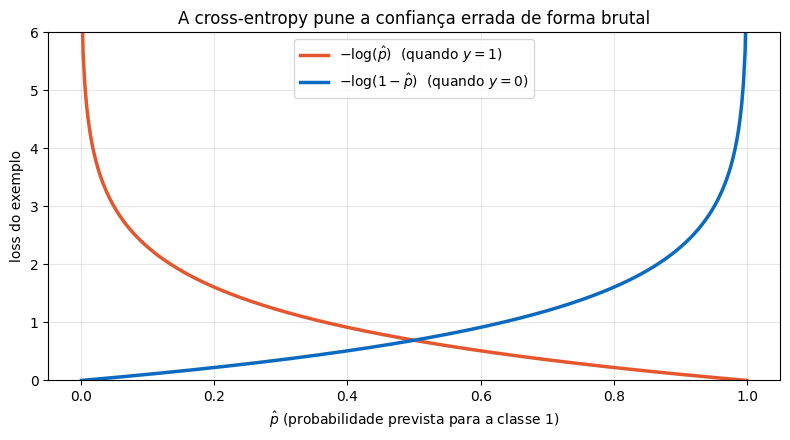

In [6]:
p = np.linspace(0.001, 0.999, 400)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(p, -np.log(p), color="#E4572E", linewidth=2.5, label="$-\\log(\\hat{p})$  (quando $y = 1$)")
ax.plot(p, -np.log(1 - p), color="#0A6ABF", linewidth=2.5, label="$-\\log(1 - \\hat{p})$  (quando $y = 0$)")
ax.set_xlabel("$\\hat{p}$ (probabilidade prevista para a classe 1)")
ax.set_ylabel("loss do exemplo")
ax.set_ylim(0, 6)
ax.set_title("A cross-entropy pune a confiança errada de forma brutal")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Treinando a regressão logística

O gradiente da BCE em relação aos parâmetros tem exatamente a mesma forma "erro vezes entrada" da regressão linear (a derivação passo a passo fica para o próximo artigo da série):

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big(\hat{p}^{(i)} - y^{(i)}\big)\, x^{(i)}, \qquad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big(\hat{p}^{(i)} - y^{(i)}\big)$$

In [7]:
def modelo(X, w, b):
    """Probabilidade prevista para a classe 1: sigmoid da saida linear."""
    return sigmoid(X @ w + b)


def gradiente(X, y, w, b):
    """Derivadas parciais da BCE: a forma 'erro vezes entrada'."""
    erro = modelo(X, w, b) - y
    dw = X.T @ erro / len(y)
    db = np.mean(erro)
    return dw, db


def gradient_descent(X, y, w, b, alpha, n_iter):
    """Treina a regressao logistica, retornando parametros e historico da cost."""
    historico = []
    for _ in range(n_iter):
        dw, db = gradiente(X, y, w, b)
        w = w - alpha * dw      # atualizacao simultanea
        b = b - alpha * db
        historico.append(bce(y, modelo(X, w, b)))
    return w, b, historico


w, b, historico = gradient_descent(X, y, w=np.zeros(2), b=0.0, alpha=0.1, n_iter=3000)

y_pred = (modelo(X, w, b) >= 0.5).astype(float)
acuracia = np.mean(y_pred == y)

print(f"w treinado = [{w[0]:.3f}, {w[1]:.3f}]")
print(f"b treinado = {b:.3f}")
print(f"BCE inicial = {historico[0]:.4f}")
print(f"BCE final   = {historico[-1]:.4f}")
print(f"acurácia    = {acuracia:.3f}")

w treinado = [1.610, 1.167]
b treinado = -7.924
BCE inicial = 0.6157
BCE final   = 0.0941
acurácia    = 0.965


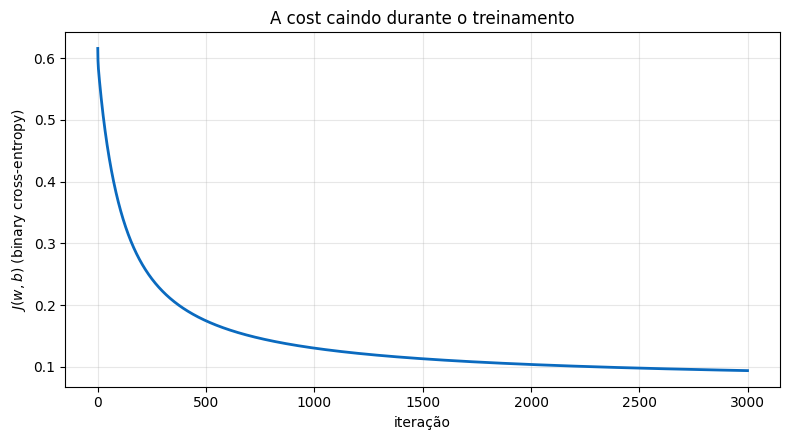

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(historico, color="#0A6ABF", linewidth=2)
ax.set_xlabel("iteração")
ax.set_ylabel("$J(w, b)$ (binary cross-entropy)")
ax.set_title("A cost caindo durante o treinamento")
plt.tight_layout()
plt.show()

## 5. A fronteira de decisão

O modelo prevê classe 1 quando $\hat{p} \geq 0{,}5$, ou seja, quando $z = w^\top x + b \geq 0$. A fronteira de decisão é a reta $w^\top x + b = 0$. O fundo colorido mostra a probabilidade prevista em cada região do plano.

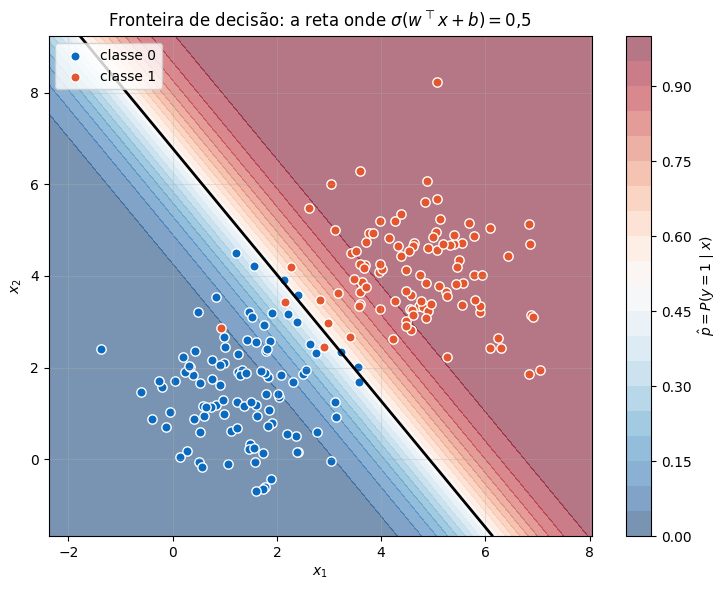

In [9]:
x1_grid, x2_grid = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300),
)
grid = np.c_[x1_grid.ravel(), x2_grid.ravel()]
probs = modelo(grid, w, b).reshape(x1_grid.shape)

fig, ax = plt.subplots(figsize=(7.5, 6))
cs = ax.contourf(x1_grid, x2_grid, probs, levels=20, cmap="RdBu_r", alpha=0.55)
ax.contour(x1_grid, x2_grid, probs, levels=[0.5], colors="black", linewidths=2)
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#0A6ABF", edgecolor="white", s=45, label="classe 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#E4572E", edgecolor="white", s=45, label="classe 1")
fig.colorbar(cs, ax=ax, label="$\\hat{p} = P(y = 1 \\mid x)$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Fronteira de decisão: a reta onde $\\sigma(w^\\top x + b) = 0{,}5$")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---

Este notebook acompanha o artigo completo no blog: [sigmoidal.ai](https://sigmoidal.ai)